# Currency Volatility

How bumpy has the zloty's ride against USD, EUR and GBP really been? This notebook pulls daily reference rates straight from the **NBP (Narodowy Bank Polski) Web API** — public, no API key required — and plots each currency's rolling 30-day volatility (annualised standard deviation of daily returns) over the last 5 years.

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import pandas as pd
import requests

NBP_API = "https://api.nbp.pl/api/exchangerates/rates/A/{code}/{start}/{end}/?format=json"
CURRENCIES = ["USD", "EUR", "GBP"]
YEARS_BACK = 5


def fetch_rates(code: str, years_back: int = YEARS_BACK) -> pd.Series:
    """Fetch daily NBP mid rates for `code`, working around the API's 367-day range limit."""
    end = dt.date.today()
    start = end.replace(year=end.year - years_back)

    frames = []
    chunk_start = start
    while chunk_start < end:
        chunk_end = min(chunk_start + dt.timedelta(days=366), end)
        url = NBP_API.format(code=code, start=chunk_start.isoformat(), end=chunk_end.isoformat())
        response = requests.get(url, timeout=15)
        if response.ok:
            frames.append(pd.DataFrame(response.json()["rates"]))
        chunk_start = chunk_end + dt.timedelta(days=1)

    df = pd.concat(frames, ignore_index=True)
    df["effectiveDate"] = pd.to_datetime(df["effectiveDate"])
    return df.set_index("effectiveDate")["mid"].rename(code)


rates = pd.concat([fetch_rates(code) for code in CURRENCIES], axis=1).sort_index()
rates.tail()

,USD,EUR,GBP
effectiveDate,,,
2026-09-11,3.7267,4.3228,5.0332
2026-09-14,3.7607,4.3391,5.0705
2026-09-15,3.7667,4.3445,5.0756
2026-09-16,3.7639,4.3435,5.0703
2026-09-17,3.8030,4.3632,5.0942


## Rolling volatility

Daily percentage moves, smoothed over a 30-day window and annualised so the three currencies are directly comparable.

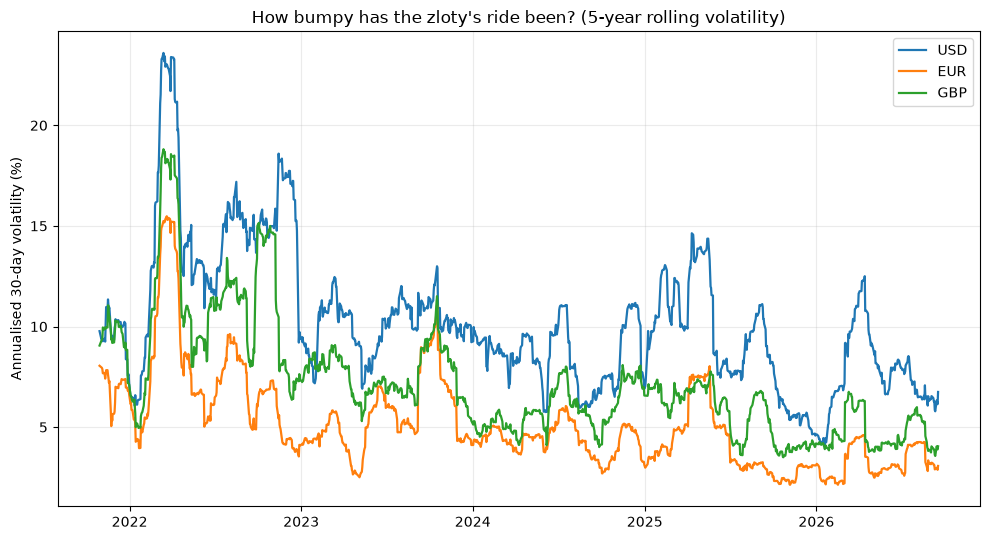

In [2]:
daily_returns = rates.pct_change()
volatility = daily_returns.rolling(30).std() * (252 ** 0.5) * 100  # annualised, in %

fig, ax = plt.subplots(figsize=(10, 5.5))
for currency in CURRENCIES:
    ax.plot(volatility.index, volatility[currency], label=currency, linewidth=1.6)

ax.set_title(f"How bumpy has the zloty's ride been? ({YEARS_BACK}-year rolling volatility)")
ax.set_ylabel("Annualised 30-day volatility (%)")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Biggest single-day moves

In [3]:
biggest_moves = daily_returns.abs().stack().sort_values(ascending=False).head(5)
for (date, currency), move in biggest_moves.items():
    print(f"{date.date()}  {currency}  {move * 100:+.2f}%")

2022-03-07  USD  +4.13%
2022-11-14  USD  +4.11%
2022-02-24  USD  +3.37%
2022-09-26  GBP  +3.13%
2022-03-07  GBP  +3.08%
